In [1]:
from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=2, memory_limit='2GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44413,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 7.45 GiB
Comm: tcp://127.0.0.1:44993,Total threads: 2
Dashboard: http://127.0.0.1:42447/status,Memory: 1.86 GiB
Nanny: tcp://127.0.0.1:33235,


In [2]:
from pathlib import Path

import xarray as xr
import rioxarray
import numpy as np
import geopandas as gpd

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
import xgboost as xgb

from pystac_client import Client as StacClient
import odc.stac
import planetary_computer as pc

time = ("2020-08-01", "2020-08-31")
S2_L2A_RESOLUTION = 10
S2_L2A_MEASUREMENTS = ["B02", "B03", "B04", "B05", "B06","B07","B08","B8A","B09", "B11", "B12", "SCL"]

catalog = StacClient.open("https://planetarycomputer.microsoft.com/api/stac/v1")

odc.stac.configure_rio(cloud_defaults=True, client=client)

In [3]:
# Load fitted model from disk
model = xgb.XGBClassifier()
model.load_model("./model_XGB_Bari.json")

model.best_iteration

199

In [4]:
# Load label encoder
import pickle 
with open('./label_encoder.pkl', 'rb') as f: 
      label_encoder = pickle.load(f)

## Inference example 1

In [2]:
# Retrieve reference bounding box
gt = rioxarray.open_rasterio('Bari_gt_clipped.tif')
bbox = gt.rio.transform_bounds("EPSG:4326")

In [3]:
# Search available items in the STAC catalog with given parameters 
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=time,
    query={"eo:cloud_cover": {"lt": 60}},
)
items = search.get_all_items()

# Load retrieved STAC items into a Xarray Dataset
ds = stac_load(
    items,
    time=time,
    stac_cfg=CFG,
    bands=S2_L2A_MEASUREMENTS,
    # resolution=S2_L2A_RESOLUTION,
    group_by="solar_day",
    fail_on_error=False,
    like=gt,
    patch_url=pc.sign,
)

# Mask cloudy pixels
ds = ds.where(ds.SCL <= 7)
ds = ds.drop("SCL")

# Median Composition
ds = ds.median(dim='time', skipna=True)
coords = ds.coords

ds = ds.to_stacked_array("z", sample_dims=["x","y"])

cols = ds.x.size
rows = ds.y.size
bands = ds.z.size

ds = ds.data
cloud_mask = np.isnan(ds).any(axis=2)

ds = np.reshape(ds, (rows*cols, bands))
ds.shape

(3252174, 11)

In [5]:
# Predict samples
y_pred = model.predict(ds)
y_pred

array([5, 5, 5, ..., 1, 1, 1])

In [6]:
# Predict classes probabilities
model.predict_proba(ds)

array([[2.0503963e-07, 5.2357727e-08, 3.6501404e-09, 8.7556352e-08,
        6.1896714e-07, 9.9999905e-01],
       [2.0715171e-07, 5.2103793e-08, 3.6501404e-09, 8.7556352e-08,
        5.8360797e-07, 9.9999905e-01],
       [2.1666753e-07, 5.2103807e-08, 3.6501413e-09, 8.7556373e-08,
        3.9966847e-07, 9.9999928e-01],
       ...,
       [6.2894111e-04, 6.1640203e-01, 1.9592595e-01, 1.8480241e-01,
        2.2396368e-03, 9.7827831e-07],
       [1.5593188e-04, 5.5639124e-01, 3.3805498e-01, 1.0474784e-01,
        6.4873981e-04, 1.3016363e-06],
       [3.2980859e-04, 6.7186666e-01, 1.7964555e-01, 1.4767969e-01,
        4.7706332e-04, 1.2031145e-06]], dtype=float32)

In [8]:
y_pred = label_encoder.inverse_transform(y_pred).astype("uint8")
del ds
y_pred

array([80, 80, 80, ..., 20, 20, 20], dtype=uint8)

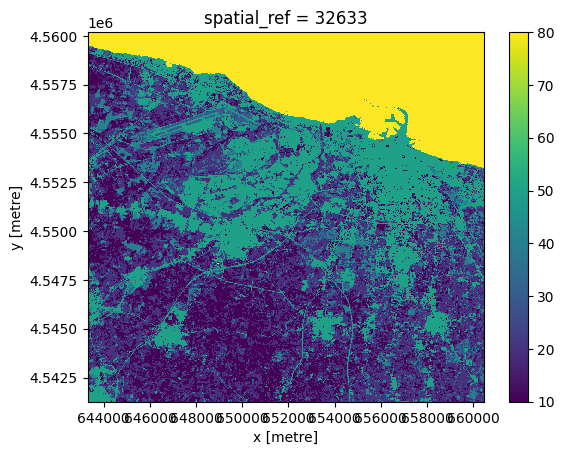

In [9]:
# Reshape 1D predictions in 2D matrix
img = np.reshape(y_pred, (rows, cols))

# Contruct Xarray DataArray using input coordinates
img_da = xr.DataArray(
    data=img,
    coords=coords
)
img_da.plot()

In [10]:
# Mask nodata pixels
img_da = img_da.where(~cloud_mask, 255)

# Set nodata metadata
img_da = img_da.rio.set_nodata(255)

# Save image on disk
img_da.rio.to_raster("./Bari_predicted.tif")

del img, img_da, y_pred

## Inference Example 2

In [5]:
gdf_aoi = gpd.read_file("switzerland.geojson")
bbox = gdf_aoi.total_bounds
bbox

array([ 5.95596313, 45.81922927, 10.49228668, 47.8084855 ])

In [7]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=gdf_aoi.geometry[0],
    datetime=time,
    query={
        "eo:cloud_cover": {"lt": 90}
    }
)
items = search.item_collection()
print(f"Found: {len(items)} datasets")

ds = odc.stac.load(
    items,
    time=time,
    bands=S2_L2A_MEASUREMENTS,
    resolution=100,
    dtype='uint16',
    nodata=0,
    geopolygon=gdf_aoi.__geo_interface__,
    group_by="solar_day",
    fail_on_error=False,
    patch_url=pc.sign,
    chunks={'x': 1024, 'y': 1024, 'time': -1},
)

# Mask nodata value (0) as np.NaN
ds = ds.where(ds != 0)

# Mask cloudy pixels
ds = ds.where(ds.SCL <= 7)
ds = ds.drop_vars("SCL")

# Median Composition
ds = ds.median(dim='time', skipna=True)
coords = ds.coords

# Convert back to uint16, replacing NaN with 0
ds = ds.fillna(0).astype("uint16")

ds = ds.to_stacked_array("bands", sample_dims=["x","y"])

cols = ds.x.size
rows = ds.y.size
bands = ds.bands.size

cloud_mask = (ds == 0).any(dim='bands')
ds = ds.data

ds = np.reshape(ds, (rows*cols, bands))

y_pred = model.predict(ds)
y_pred = label_encoder.inverse_transform(y_pred).astype("uint8")
img = np.reshape(y_pred, (rows, cols))

img_da = xr.DataArray(
    data=img,
    coords=coords
)
del img, ds, y_pred

img_da = img_da.where(~cloud_mask, 255)
img_da = img_da.rio.set_nodata(255)
img_da.rio.to_raster("LC_switzerland_predicted.tif")

Found: 153 datasets


/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
2025-02-15 17:50:26,972 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 1.51 GiB -- Worker memory limit: 1.86 GiB
2025-02-15 17:50:27,281 - 

In [8]:
client.close()